# Pokémon Conditional Diffusion Model

Generates new Pokémon sprites conditioned on **type** (18), **style** (3: 3d, sugimori, sprite), **evolution stage** (3: base, evo1, evo2), and an **optional previous evolution image**.

## JSON schema (as it is on disk)
Each entry:
```
{
  "next_sprite": "path/to/target.png",
  "prev_sprite": "path/to/prev.png" or null,
  "types": ["grass", "poison"],
  "evolution_stage": "base" | "evo 1" | "evo 2",
  "art_style": "sprite" | "3d" | "sugimori"
}
```

## Key fixes vs. the original
- **Cosine noise schedule** now uses the Nichol & Dhariwal alpha-bar formulation (the previous
  version was `sin²(t)` clamped flat).
- **Stage key mismatch** — the JSON uses `"evo 1"`/`"evo 2"` with spaces; the mapping now handles
  both forms so evo1/evo2 are actually conditioned on (was silently collapsing to base).
- **Per-sample CFG dropout at 10%** (was a batch-level 5% coin flip).
- **Plain MSE loss** (the alpha-masked loss prevented the model from learning the background /
  alpha channel).
- **U-Net rewrite** using the standard diffusers-style down/mid/up block pattern — the skip
  bookkeeping and attention-placement in the original were asymmetric.
- **Smaller default model** (`BASE_CH=64`) — 7.3k images does not support a 150M-param model.
- **Mixed precision training** (`torch.amp.autocast` + `GradScaler`).
- **DDIM sampler for mid-training previews** (50 steps instead of 1000).
- **Best-of-last-K early stopping** on training loss (instead of a broken monotonic counter).


In [1]:
# Cell 1: Imports & device
import os, json, math, random, shutil
from pathlib import Path
import numpy as np
from PIL import Image
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

if torch.cuda.is_available():
    props = torch.cuda.get_device_properties(0)
    print(f"GPU: {props.name}  |  VRAM: {props.total_memory / 1024**3:.1f} GB")


Using device: cuda
GPU: NVIDIA A100-SXM4-40GB  |  VRAM: 39.5 GB


In [4]:
# Cell 2: Hyperparameters

# Paths
DATA_DIR = "./poke-data"
JSON_FILES = ["3d.json", "sugimori.json", "sprite.json"]
OUTPUT_DIR = "./outputs"
CHECKPOINT_DIR = "./checkpoints"

# --- Image ---
IMG_SIZE = 64            # start at 64; bump to 128 once you confirm things learn
IMG_CHANNELS = 4         # RGBA

# --- Conditioning ---
NUM_TYPES = 18
NUM_STYLES = 3
NUM_STAGES = 3
COND_VEC_DIM = NUM_TYPES + NUM_STYLES + NUM_STAGES   # = 24
COND_EMBED_DIM = 128

# --- Diffusion ---
TIMESTEPS = 1000
CFG_DROPOUT = 0.1        # per-sample unconditional-training rate
DDIM_STEPS = 50          # for fast sampling during training

# --- Training ---
BATCH_SIZE = 64
NUM_EPOCHS = 300
LEARNING_RATE = 2e-4
WEIGHT_DECAY = 1e-4
EMA_DECAY = 0.9999
GRAD_CLIP = 1.0
USE_AMP = True

# --- U-Net ---
BASE_CH = 64
CH_MULTS = (1, 2, 2, 4)
NUM_RES_BLOCKS = 2
ATTN_RESOLUTIONS = (16, 8)
DROPOUT = 0.1

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(CHECKPOINT_DIR, exist_ok=True)


In [5]:
# Cell 3: Attribute mappings

TYPE_TO_IDX = {
    "normal": 0, "fire": 1, "water": 2, "electric": 3,
    "grass": 4, "ice": 5, "fighting": 6, "poison": 7,
    "ground": 8, "flying": 9, "psychic": 10, "bug": 11,
    "rock": 12, "ghost": 13, "dragon": 14, "dark": 15,
    "steel": 16, "fairy": 17,
}

STYLE_TO_IDX = {"3d": 0, "sugimori": 1, "sprite": 2}

# Accept both "evo1" and "evo 1" — the JSON on disk uses the spaced form
STAGE_TO_IDX = {
    "base": 0,
    "evo 1": 1,
    "evo 2": 2,
}

TYPES = list(TYPE_TO_IDX.keys())
STYLES = list(STYLE_TO_IDX.keys())
STAGES = ["base", "evo1", "evo2"]

print(f"Types: {len(TYPE_TO_IDX)}  |  Styles: {len(STYLE_TO_IDX)}  |  Stages: 3")

Types: 18  |  Styles: 3  |  Stages: 3


In [6]:
# Cell 4: File-existence sanity check

def check_files(data_dir, json_files):
    data_dir = Path(data_dir)
    print("Indexing files on disk...")
    all_files = {str(p) for p in data_dir.rglob("*") if p.is_file()}
    print(f"Found {len(all_files)} files on disk")

    missing, null_targets, total = [], [], 0
    for jf in json_files:
        json_path = data_dir / jf
        if not json_path.exists():
            print(f"✗ Missing JSON: {json_path}")
            continue
        entries = json.load(open(json_path))
        for i, entry in enumerate(entries):
            total += 1
            if entry.get("next_sprite") is None:
                null_targets.append(f"{jf}[{i}]")
            for field in ("next_sprite", "prev_sprite"):
                val = entry.get(field)
                if val is None: continue
                full = str(data_dir / val)
                if full not in all_files:
                    missing.append(f"{jf}[{i}] {field}: {val}")

    if null_targets:
        print(f"{len(null_targets)} entries with null next_sprite")
    if missing:
        print(f"✗ {len(missing)}/{total} files missing. First few:")
        for m in missing[:10]: print(f"  - {m}")
    else:
        print(f"All files present ({total} entries checked)")

check_files(DATA_DIR, JSON_FILES)


Indexing files on disk...
Found 7738 files on disk
All files present (6372 entries checked)


In [7]:
# Cell 5: Dataset

class PokemonDiffusionDataset(Dataset):
    """
    Loads entries from multiple JSON files. Target = next_sprite, conditioning = prev_sprite
    + (types, stage, style). Missing prev_sprite (base Pokemon) → zero image + has_prev=0.
    """

    def __init__(self, data_dir, json_files, img_size=64):
        self.data_dir = Path(data_dir)
        self.img_size = img_size
        self.samples = []

        for jf in json_files:
            path = self.data_dir / jf
            if not path.exists():
                print(f"Warning: {path} not found, skipping.")
                continue
            entries = json.load(open(path))
            # keep only entries with a valid target
            entries = [e for e in entries if e.get("next_sprite") is not None]
            # tag each entry with its source style so weight computation is trivial later
            for e in entries:
                e["_source"] = jf
            self.samples.extend(entries)
            print(f"Loaded {len(entries)} samples from {jf}")
        print(f"Total dataset size: {len(self.samples)}")

        self.transform = transforms.Compose([
            transforms.Resize((img_size, img_size)),
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1, hue=0.05),
            transforms.ToTensor(),
            transforms.Lambda(lambda x: x * 2 - 1),
        ])

    def _load_image(self, rel_path):
        img = Image.open(self.data_dir / rel_path).convert("RGBA")
        return self.transform(img)

    def _encode_type(self, type_val):
        vec = torch.zeros(NUM_TYPES)
        if isinstance(type_val, str):
            type_val = [type_val]
        for t in type_val:
            key = t.lower().strip()
            if key in TYPE_TO_IDX:
                vec[TYPE_TO_IDX[key]] = 1.0
        return vec

    def _encode_style(self, style_val):
        vec = torch.zeros(NUM_STYLES)
        vec[STYLE_TO_IDX.get(style_val.lower().strip(), 0)] = 1.0
        return vec

    def _encode_stage(self, stage_val):
        vec = torch.zeros(NUM_STAGES)
        key = stage_val.lower().strip() if isinstance(stage_val, str) else stage_val
        vec[STAGE_TO_IDX.get(key, 0)] = 1.0
        return vec

    def __getitem__(self, idx):
      # Odd indices → flipped version of the even index
      flipped = idx >= len(self.samples)
      real_idx = idx % len(self.samples)
      s = self.samples[real_idx]

      target = self._load_image(s["next_sprite"])
      if s.get("prev_sprite") is not None:
          prev_evo = self._load_image(s["prev_sprite"])
          has_prev = torch.tensor(1.0)
      else:
          prev_evo = torch.zeros(IMG_CHANNELS, self.img_size, self.img_size)
          has_prev = torch.tensor(0.0)

      if flipped:
          target = transforms.functional.hflip(target)
          prev_evo = transforms.functional.hflip(prev_evo)

      cond_vec = torch.cat([
                  self._encode_type(s["types"]),
                  self._encode_style(s["art_style"]),
                  self._encode_stage(s["evolution_stage"]),
                  ])
      return {"target": target, "prev_evo": prev_evo, "has_prev": has_prev, "cond_vec": cond_vec}

    def __len__(self):
      return len(self.samples) * 2

In [8]:
# Cell 6: Noise schedule (proper cosine, Nichol & Dhariwal 2021)

class NoiseSchedule:
    def __init__(self, timesteps=1000, device="cpu", s=0.008):
        self.timesteps = timesteps
        self.device = device

        # Cosine schedule on alpha_bar directly
        t = torch.linspace(0, 1, timesteps + 1, device=device)
        alpha_bar = torch.cos(((t + s) / (1 + s)) * math.pi / 2) ** 2
        alpha_bar = alpha_bar / alpha_bar[0]
        betas = (1 - alpha_bar[1:] / alpha_bar[:-1]).clamp(max=0.999)

        self.betas = betas
        self.alphas = 1.0 - betas
        self.alpha_cumprod = torch.cumprod(self.alphas, dim=0)
        self.alpha_cumprod_prev = F.pad(self.alpha_cumprod[:-1], (1, 0), value=1.0)

        self.sqrt_alpha_cumprod = torch.sqrt(self.alpha_cumprod)
        self.sqrt_one_minus_alpha_cumprod = torch.sqrt(1.0 - self.alpha_cumprod)
        self.sqrt_recip_alpha = torch.sqrt(1.0 / self.alphas)
        self.posterior_variance = betas * (1.0 - self.alpha_cumprod_prev) / (1.0 - self.alpha_cumprod)

    def add_noise(self, x_0, t, noise=None):
        if noise is None:
            noise = torch.randn_like(x_0)
        sqrt_ab   = self.sqrt_alpha_cumprod[t].view(-1, 1, 1, 1)
        sqrt_1mab = self.sqrt_one_minus_alpha_cumprod[t].view(-1, 1, 1, 1)
        return sqrt_ab * x_0 + sqrt_1mab * noise, noise

    # ---- DDPM reverse step ----
    def _apply_step(self, x_t, t, pred_noise):
        betas_t      = self.betas[t].view(-1, 1, 1, 1)
        sqrt_1mab_t  = self.sqrt_one_minus_alpha_cumprod[t].view(-1, 1, 1, 1)
        sqrt_recip_t = self.sqrt_recip_alpha[t].view(-1, 1, 1, 1)
        mean = sqrt_recip_t * (x_t - betas_t / sqrt_1mab_t * pred_noise)
        if t == 0:
            return mean
        var = self.posterior_variance[t].view(-1, 1, 1, 1)
        return mean + torch.sqrt(var) * torch.randn_like(x_t)

    def _run_cfg(self, model, x_t, t_tensor, cond, prev, has_prev, guidance_scale):
        if guidance_scale == 1.0:
            return model(x_t, t_tensor, cond, prev, has_prev)
        # unconditional pass zeros BOTH attribute conditioning and prev-evo signal
        cond_null = torch.zeros_like(cond)
        prev_null = torch.zeros_like(prev)
        has_prev_null = torch.zeros_like(has_prev)
        pred_cond   = model(x_t, t_tensor, cond, prev, has_prev)
        pred_uncond = model(x_t, t_tensor, cond_null, prev_null, has_prev_null)
        return pred_uncond + guidance_scale * (pred_cond - pred_uncond)

    @torch.no_grad()
    def ddpm_sample(self, model, shape, cond, prev, has_prev, guidance_scale=1.0, progress=True):
        x = torch.randn(shape, device=self.device)
        it = reversed(range(self.timesteps))
        if progress: it = tqdm(it, total=self.timesteps, desc="DDPM")
        for t in it:
            t_tensor = torch.full((shape[0],), t, device=self.device, dtype=torch.long)
            pred_noise = self._run_cfg(model, x, t_tensor, cond, prev, has_prev, guidance_scale)
            x = self._apply_step(x, t, pred_noise)
        return x.clamp(-1, 1)

    # ---- DDIM (deterministic, much faster for previews) ----
    @torch.no_grad()
    def ddim_sample(self, model, shape, cond, prev, has_prev, num_steps=50,
                    guidance_scale=1.0, eta=0.0, progress=True):
        step_indices = torch.linspace(self.timesteps - 1, 0, num_steps + 1, device=self.device).long()
        x = torch.randn(shape, device=self.device)
        rng = range(num_steps)
        if progress: rng = tqdm(rng, desc="DDIM")
        for i in rng:
            t = step_indices[i].item()
            t_prev = step_indices[i + 1].item()
            t_tensor = torch.full((shape[0],), t, device=self.device, dtype=torch.long)
            eps = self._run_cfg(model, x, t_tensor, cond, prev, has_prev, guidance_scale)

            a_t  = self.alpha_cumprod[t]
            a_tp = self.alpha_cumprod[t_prev] if t_prev >= 0 else torch.tensor(1.0, device=self.device)
            x0_pred = (x - torch.sqrt(1 - a_t) * eps) / torch.sqrt(a_t)
            x0_pred = x0_pred.clamp(-1, 1)

            sigma = eta * torch.sqrt((1 - a_tp) / (1 - a_t) * (1 - a_t / a_tp))
            dir_xt = torch.sqrt((1 - a_tp - sigma ** 2).clamp(min=0)) * eps
            x = torch.sqrt(a_tp) * x0_pred + dir_xt
            if eta > 0 and t_prev > 0:
                x = x + sigma * torch.randn_like(x)
        return x.clamp(-1, 1)


In [9]:
# Cell 7: U-Net building blocks

class SinusoidalPosEmb(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim
    def forward(self, t):
        half = self.dim // 2
        freqs = torch.exp(-math.log(10000) * torch.arange(half, device=t.device) / (half - 1))
        args = t.float().unsqueeze(1) * freqs.unsqueeze(0)
        return torch.cat([torch.sin(args), torch.cos(args)], dim=1)


class ResBlock(nn.Module):
    """GroupNorm → SiLU → Conv → (time-emb shift) → GroupNorm → SiLU → Dropout → Conv + skip."""
    def __init__(self, in_ch, out_ch, emb_dim, dropout=0.1):
        super().__init__()
        self.norm1 = nn.GroupNorm(8, in_ch)
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=1)
        self.emb_proj = nn.Linear(emb_dim, out_ch)
        self.norm2 = nn.GroupNorm(8, out_ch)
        self.dropout = nn.Dropout(dropout)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1)
        self.skip = nn.Conv2d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()

    def forward(self, x, emb):
        h = self.conv1(F.silu(self.norm1(x)))
        h = h + self.emb_proj(F.silu(emb)).unsqueeze(-1).unsqueeze(-1)
        h = self.conv2(self.dropout(F.silu(self.norm2(h))))
        return h + self.skip(x)


class SelfAttention(nn.Module):
    def __init__(self, channels, num_heads=4):
        super().__init__()
        self.norm = nn.GroupNorm(8, channels)
        self.attn = nn.MultiheadAttention(channels, num_heads, batch_first=True)

    def forward(self, x):
        B, C, H, W = x.shape
        h = self.norm(x).view(B, C, H * W).transpose(1, 2)
        h, _ = self.attn(h, h, h)
        return x + h.transpose(1, 2).view(B, C, H, W)


class Downsample(nn.Module):
    def __init__(self, ch):
        super().__init__()
        self.op = nn.Conv2d(ch, ch, 3, stride=2, padding=1)
    def forward(self, x): return self.op(x)


class Upsample(nn.Module):
    def __init__(self, ch):
        super().__init__()
        self.op = nn.Conv2d(ch, ch, 3, padding=1)
    def forward(self, x):
        x = F.interpolate(x, scale_factor=2, mode="nearest")
        return self.op(x)


In [10]:
# Cell 8: Conditional U-Net (diffusers-style down/mid/up with explicit skip list)

class ConditionalUNet(nn.Module):
    def __init__(self, img_channels=4, prev_channels=4, cond_vec_dim=24,
                 cond_embed_dim=128, base_ch=64, ch_mults=(1, 2, 2, 4),
                 num_res_blocks=2, attn_resolutions=(16, 8), dropout=0.1, img_size=64):
        super().__init__()
        self.img_size = img_size
        self.num_res_blocks = num_res_blocks
        self.ch_mults = ch_mults
        self.attn_resolutions = set(attn_resolutions)

        emb_dim = cond_embed_dim * 4   # carry time + cond as one high-dim vector

        # --- Time embedding ---
        self.time_mlp = nn.Sequential(
            SinusoidalPosEmb(cond_embed_dim),
            nn.Linear(cond_embed_dim, emb_dim),
            nn.SiLU(),
            nn.Linear(emb_dim, emb_dim),
        )

        # --- Attribute embedding ---
        self.cond_mlp = nn.Sequential(
            nn.Linear(cond_vec_dim, emb_dim),
            nn.SiLU(),
            nn.Linear(emb_dim, emb_dim),
        )

        # --- Prev-evo encoder (wider bottleneck than before, 256-d) ---
        self.prev_encoder = nn.Sequential(
            nn.Conv2d(prev_channels, 32, 4, 2, 1), nn.SiLU(),
            nn.Conv2d(32, 64, 4, 2, 1),            nn.SiLU(),
            nn.Conv2d(64, 128, 4, 2, 1),           nn.SiLU(),
            nn.Conv2d(128, 256, 4, 2, 1),          nn.SiLU(),
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(256, emb_dim),
        )

        # --- Init conv ---
        self.init_conv = nn.Conv2d(img_channels, base_ch, 3, padding=1)

        # --- Down blocks ---
        # Track channel sizes at each skip so the decoder can unambiguously pair them up.
        self.downs = nn.ModuleList()
        ch = base_ch
        skip_channels = [ch]    # after init_conv
        cur_res = img_size

        for level, mult in enumerate(ch_mults):
            out_ch = base_ch * mult
            for _ in range(num_res_blocks):
                block = nn.ModuleDict({
                    "res":  ResBlock(ch, out_ch, emb_dim, dropout),
                    "attn": SelfAttention(out_ch) if cur_res in self.attn_resolutions else nn.Identity(),
                })
                self.downs.append(block)
                ch = out_ch
                skip_channels.append(ch)

            if level < len(ch_mults) - 1:
                self.downs.append(nn.ModuleDict({"down": Downsample(ch)}))
                skip_channels.append(ch)
                cur_res //= 2

        # --- Middle ---
        self.mid = nn.ModuleList([
            ResBlock(ch, ch, emb_dim, dropout),
            SelfAttention(ch),
            ResBlock(ch, ch, emb_dim, dropout),
        ])

        # --- Up blocks ---
        self.ups = nn.ModuleList()
        for level, mult in reversed(list(enumerate(ch_mults))):
            out_ch = base_ch * mult
            for _ in range(num_res_blocks + 1):
                skip_ch = skip_channels.pop()
                block = nn.ModuleDict({
                    "res":  ResBlock(ch + skip_ch, out_ch, emb_dim, dropout),
                    "attn": SelfAttention(out_ch) if cur_res in self.attn_resolutions else nn.Identity(),
                })
                self.ups.append(nn.ModuleDict({**block}))
                ch = out_ch

            if level > 0:
                self.ups.append(nn.ModuleDict({"up": Upsample(ch)}))
                cur_res *= 2

        # --- Output ---
        self.final_norm = nn.GroupNorm(8, ch)
        self.final_conv = nn.Conv2d(ch, img_channels, 3, padding=1)

    def forward(self, x, t, cond_vec, prev_evo, has_prev):
        # Build combined embedding: time + cond + (masked) prev
        t_emb = self.time_mlp(t)
        c_emb = self.cond_mlp(cond_vec)
        p_emb = self.prev_encoder(prev_evo) * has_prev.unsqueeze(1)
        emb = t_emb + c_emb + p_emb

        # Encoder
        h = self.init_conv(x)
        skips = [h]
        for block in self.downs:
            if "down" in block:
                h = block["down"](h)
                skips.append(h)
            else:
                h = block["res"](h, emb)
                if not isinstance(block["attn"], nn.Identity):
                    h = block["attn"](h)
                skips.append(h)

        # Middle
        h = self.mid[0](h, emb)
        h = self.mid[1](h)
        h = self.mid[2](h, emb)

        # Decoder
        for block in self.ups:
            if "up" in block:
                h = block["up"](h)
            else:
                h = torch.cat([h, skips.pop()], dim=1)
                h = block["res"](h, emb)
                if not isinstance(block["attn"], nn.Identity):
                    h = block["attn"](h)

        return self.final_conv(F.silu(self.final_norm(h)))


# --- Dimension + param check ---
_model = ConditionalUNet(
    img_channels=IMG_CHANNELS, prev_channels=IMG_CHANNELS,
    cond_vec_dim=COND_VEC_DIM, cond_embed_dim=COND_EMBED_DIM,
    base_ch=BASE_CH, ch_mults=CH_MULTS, num_res_blocks=NUM_RES_BLOCKS,
    attn_resolutions=ATTN_RESOLUTIONS, dropout=DROPOUT, img_size=IMG_SIZE,
).to(device)

with torch.no_grad():
    _x = torch.randn(2, IMG_CHANNELS, IMG_SIZE, IMG_SIZE, device=device)
    _t = torch.randint(0, TIMESTEPS, (2,), device=device)
    _c = torch.zeros(2, COND_VEC_DIM, device=device)
    _p = torch.zeros(2, IMG_CHANNELS, IMG_SIZE, IMG_SIZE, device=device)
    _hp = torch.zeros(2, device=device)
    _y = _model(_x, _t, _c, _p, _hp)
    assert _y.shape == _x.shape, f"{_y.shape} vs {_x.shape}"

print(f"Forward pass OK. Params: {sum(p.numel() for p in _model.parameters()):,}")
del _model


Forward pass OK. Params: 20,749,796


In [11]:
# Cell 9: EMA

class EMA:
    def __init__(self, model, decay=0.9999):
        self.model = model
        self.decay = decay
        self.shadow, self.backup = {}, {}
        for name, p in model.named_parameters():
            if p.requires_grad:
                self.shadow[name] = p.data.clone()

    @torch.no_grad()
    def update(self):
        for name, p in self.model.named_parameters():
            if p.requires_grad:
                self.shadow[name].mul_(self.decay).add_(p.data, alpha=1 - self.decay)

    def apply_shadow(self):
        for name, p in self.model.named_parameters():
            if p.requires_grad:
                self.backup[name] = p.data.clone()
                p.data.copy_(self.shadow[name])

    def restore(self):
        for name, p in self.model.named_parameters():
            if p.requires_grad:
                p.data.copy_(self.backup[name])
        self.backup = {}


In [12]:
# Cell 10: Sampling helpers

def make_cond_vec(type_names, style, stage):
    type_vec = torch.zeros(NUM_TYPES)
    if isinstance(type_names, str):
        type_names = [type_names]
    for t in type_names:
        k = t.lower().strip()
        if k in TYPE_TO_IDX:
            type_vec[TYPE_TO_IDX[k]] = 1.0

    style_vec = torch.zeros(NUM_STYLES)
    style_vec[STYLE_TO_IDX.get(style.lower().strip(), 0)] = 1.0

    stage_vec = torch.zeros(NUM_STAGES)
    key = stage.lower().strip() if isinstance(stage, str) else stage
    stage_vec[STAGE_TO_IDX.get(key, 0)] = 1.0

    return torch.cat([type_vec, style_vec, stage_vec])


@torch.no_grad()
def generate(model, noise_schedule, cond_vec, prev_evo_image=None,
             num_samples=1, guidance_scale=1.0, use_ddim=True, ddim_steps=50, progress=True):
    model.eval()
    cond = cond_vec.unsqueeze(0).expand(num_samples, -1).to(device)

    if prev_evo_image is not None:
        prev = prev_evo_image.unsqueeze(0).expand(num_samples, -1, -1, -1).to(device)
        has_prev = torch.ones(num_samples, device=device)
    else:
        prev = torch.zeros(num_samples, IMG_CHANNELS, IMG_SIZE, IMG_SIZE, device=device)
        has_prev = torch.zeros(num_samples, device=device)

    shape = (num_samples, IMG_CHANNELS, IMG_SIZE, IMG_SIZE)
    if use_ddim:
        x = noise_schedule.ddim_sample(model, shape, cond, prev, has_prev,
                                       num_steps=ddim_steps, guidance_scale=guidance_scale, progress=progress)
    else:
        x = noise_schedule.ddpm_sample(model, shape, cond, prev, has_prev,
                                       guidance_scale=guidance_scale, progress=progress)
    return (x + 1) / 2  # [0,1]


def tensor_to_pil(tensor):
    img = tensor.cpu().permute(1, 2, 0).numpy()
    img = (img * 255).clip(0, 255).astype(np.uint8)
    img[:, :, 3] = np.where(img[:, :, 3] > 128, 255, 0)
    return Image.fromarray(img)


def save_sample_grid(model, ema, noise_schedule, epoch, configs=None, samples_per_cfg=2):
    if configs is None:
        configs = [
            {"type": "fire",              "style": "3d",        "stage": "base"},
            {"type": ["grass", "poison"], "style": "sugimori",  "stage": "evo1"},
            {"type": "water",             "style": "3d",        "stage": "base"},
            {"type": "fire",              "style": "sprite",    "stage": "base"},
        ]
    ema.apply_shadow()
    try:
        all_imgs = []
        for cfg in configs:
            cond = make_cond_vec(cfg["type"], cfg["style"], cfg["stage"])
            gen = generate(model, noise_schedule, cond, num_samples=samples_per_cfg,
                           guidance_scale=2.0, use_ddim=True, ddim_steps=DDIM_STEPS, progress=False)
            for i in range(gen.shape[0]):
                all_imgs.append(tensor_to_pil(gen[i]))

        cols = samples_per_cfg
        rows = len(configs)
        grid = Image.new("RGBA", (cols * IMG_SIZE, rows * IMG_SIZE), (255, 255, 255, 255))
        for idx, img in enumerate(all_imgs):
            r, c = divmod(idx, cols)
            grid.paste(img, (c * IMG_SIZE, r * IMG_SIZE))
        path = f"{OUTPUT_DIR}/samples_epoch_{epoch}.png"
        grid.save(path)
        print(f"  Saved samples to {path}")
    finally:
        ema.restore()


Loaded 2704 samples from 3d.json
Loaded 1674 samples from sugimori.json
Loaded 1994 samples from sprite.json
Total dataset size: 6372
Total with flips: 12744


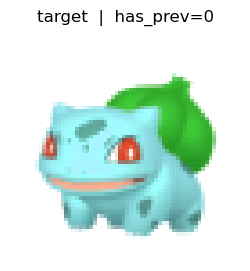

Stage distribution (idx → count): {0: 3481, 1: 2170, 2: 721}
(If this is all 0s, the stage mapping is still broken.)
Style distribution: {'3d': 2704, 'sugimori': 1674, 'sprite': 1994}


In [14]:
# Cell 11: Quick dataset sanity check
import matplotlib.pyplot as plt

_ds = PokemonDiffusionDataset(DATA_DIR, JSON_FILES, IMG_SIZE)
print(f"Total with flips: {len(_ds)}")
s = _ds[0]
img = (s["target"] + 1) / 2
plt.figure(figsize=(3, 3))
plt.imshow(img.permute(1, 2, 0)[:, :, :3])
plt.title(f"target  |  has_prev={s['has_prev'].item():.0f}")
plt.axis("off")
plt.show()

# Stage distribution — verify the stage mapping is actually working
from collections import Counter
stage_counts = Counter()
for smp in _ds.samples:
    stage_vec = _ds._encode_stage(smp["evolution_stage"])
    stage_counts[int(stage_vec.argmax())] += 1
print("Stage distribution (idx → count):", dict(stage_counts))
print("(If this is all 0s, the stage mapping is still broken.)")

style_counts = Counter(s["art_style"] for s in _ds.samples)
print("Style distribution:", dict(style_counts))
del _ds


Loaded 2704 samples from 3d.json
Loaded 1674 samples from sugimori.json
Loaded 1994 samples from sprite.json
Total dataset size: 6372
RGB min: 0.165, mean: 0.865
Pixels > 0.9 brightness: 60.77%
Pixels < 0.9 brightness: 39.23%


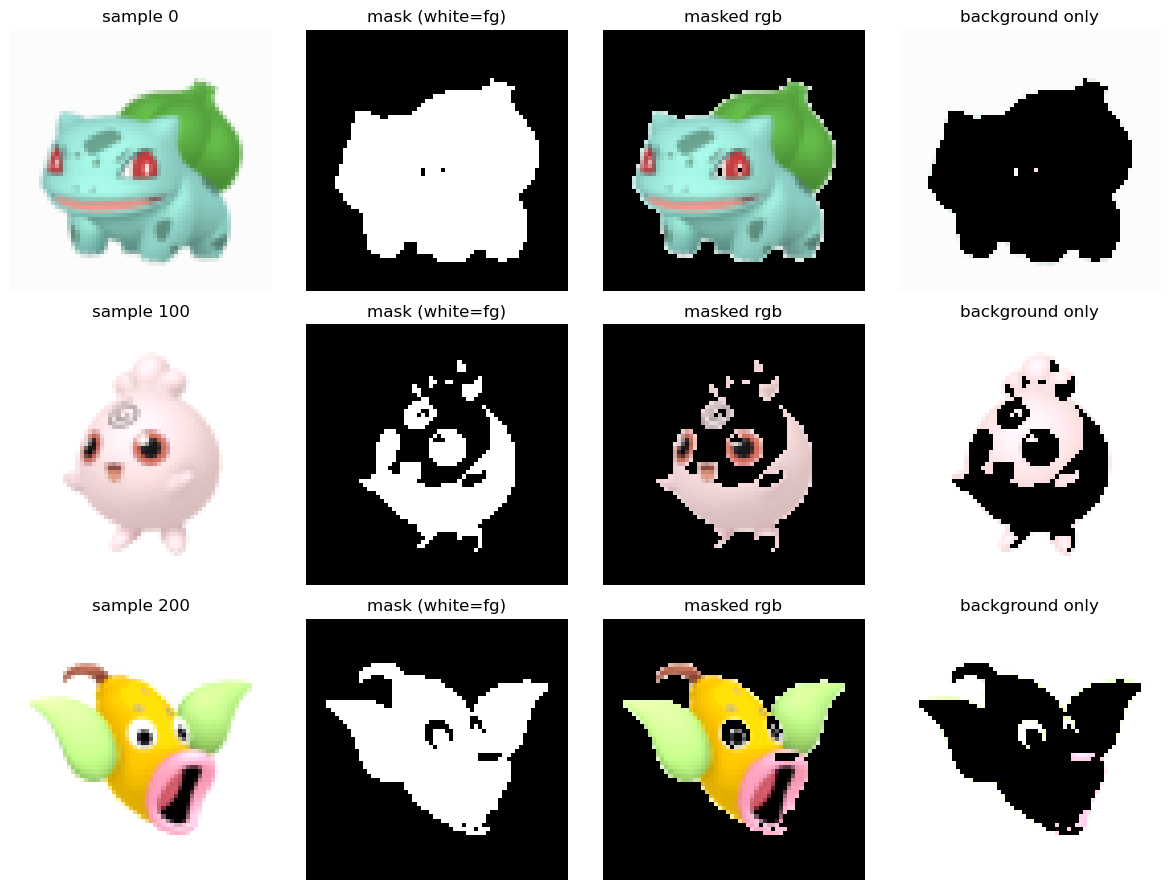

In [16]:
import matplotlib.pyplot as plt

_dataset = PokemonDiffusionDataset(DATA_DIR, JSON_FILES, IMG_SIZE)

s = _dataset[0]
rgb = (s["target"][:3] + 1) / 2
print(f"RGB min: {rgb.min():.3f}, mean: {rgb.mean():.3f}")
print(f"Pixels > 0.9 brightness: {(rgb.mean(0) > 0.9).float().mean():.2%}")
print(f"Pixels < 0.9 brightness: {(rgb.mean(0) < 0.9).float().mean():.2%}")

fig, axes = plt.subplots(3, 4, figsize=(12, 9))
for i, ax_row in enumerate(axes):
    s = _dataset[i * 100]
    rgb = (s["target"][:3] + 1) / 2
    fg_mask = (rgb.mean(dim=0) < 0.9).float()
    
    ax_row[0].imshow(rgb.permute(1, 2, 0))
    ax_row[0].set_title(f"sample {i*100}")
    ax_row[1].imshow(fg_mask, cmap="gray")
    ax_row[1].set_title("mask (white=fg)")
    ax_row[2].imshow((rgb * fg_mask.unsqueeze(0)).permute(1, 2, 0))
    ax_row[2].set_title("masked rgb")
    ax_row[3].imshow((rgb * (1 - fg_mask.unsqueeze(0)) + (1 - fg_mask.unsqueeze(0)) * 0).permute(1, 2, 0))
    ax_row[3].set_title("background only")
    for ax in ax_row: ax.axis("off")

plt.tight_layout()
plt.show()

del _dataset

In [ ]:
# Cell 12: Training

def train(resume_from=None):
    dataset = PokemonDiffusionDataset(DATA_DIR, JSON_FILES, IMG_SIZE)
    from collections import Counter
    style_counts = Counter(s["art_style"] for s in dataset.samples)
    print(f"Style counts for sampler: {dict(style_counts)}")
    weights = torch.tensor([1.0 / style_counts[s["art_style"]] for s in dataset.samples])
    sampler = WeightedRandomSampler(weights, num_samples=len(weights), replacement=True)

    dataloader = DataLoader(
        dataset, batch_size=BATCH_SIZE, sampler=sampler,
        num_workers=4, pin_memory=True, drop_last=True, persistent_workers=True,
    )

    model = ConditionalUNet(
        img_channels=IMG_CHANNELS, prev_channels=IMG_CHANNELS,
        cond_vec_dim=COND_VEC_DIM, cond_embed_dim=COND_EMBED_DIM,
        base_ch=BASE_CH, ch_mults=CH_MULTS, num_res_blocks=NUM_RES_BLOCKS,
        attn_resolutions=ATTN_RESOLUTIONS, dropout=DROPOUT, img_size=IMG_SIZE,
    ).to(device)

    optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    noise_schedule = NoiseSchedule(TIMESTEPS, device=device)
    ema = EMA(model, decay=EMA_DECAY)
    scaler = torch.amp.GradScaler("cuda", enabled=USE_AMP)

    start_epoch, best_loss = 0, float("inf")
    recent_losses = []

    if resume_from is not None and os.path.exists(resume_from):
        ckpt = torch.load(resume_from, map_location=device)
        model.load_state_dict(ckpt["model_state_dict"])
        optimizer.load_state_dict(ckpt["optimizer_state_dict"])
        # for g in optimizer.param_groups: g["lr"] = LEARNING_RATE
        if "ema_shadow" in ckpt:  ema.shadow = ckpt["ema_shadow"]
        if "scaler_state" in ckpt: scaler.load_state_dict(ckpt["scaler_state"])
        start_epoch = ckpt["epoch"]
        best_loss = ckpt.get("loss", float("inf"))
        print(f"Resumed from epoch {start_epoch}, loss: {best_loss:.4f}")

    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=max(1, NUM_EPOCHS - start_epoch)
    )

    print(f"Training on {len(dataset)} samples, {len(dataloader)} batches/epoch")
    print(f"Model params: {sum(p.numel() for p in model.parameters()):,}")

    for epoch in range(start_epoch, NUM_EPOCHS):
        model.train()
        epoch_loss_sum, n_batches = 0.0, 0

        pbar = tqdm(dataloader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS}")
        for batch in pbar:
            target   = batch["target"].to(device, non_blocking=True)
            prev_evo = batch["prev_evo"].to(device, non_blocking=True)
            has_prev = batch["has_prev"].to(device, non_blocking=True)
            cond_vec = batch["cond_vec"].to(device, non_blocking=True)

            B = target.shape[0]

            # Per-sample CFG dropout: also zero prev-evo signal for the dropped samples
            drop_mask = (torch.rand(B, device=device) < CFG_DROPOUT).float()  # (B,)
            keep = (1.0 - drop_mask)
            cond_vec = cond_vec * keep.unsqueeze(1)
            has_prev = has_prev * keep
            prev_evo = prev_evo * keep.view(B, 1, 1, 1)

            t = torch.randint(0, TIMESTEPS, (B,), device=device)
            x_t, noise = noise_schedule.add_noise(target, t)

            optimizer.zero_grad(set_to_none=True)
            with torch.amp.autocast("cuda", enabled=USE_AMP):
                pred_noise = model(x_t, t, cond_vec, prev_evo, has_prev)

                fg_mask = (target[:, :3, :, :].mean(dim=1, keepdim=True) < 0.9).float()
                weight_map = (0.2 + 0.8 * fg_mask).expand(-1, pred_noise.shape[1], -1, -1)

                sq_err = (pred_noise - noise) ** 2
                loss = (sq_err * weight_map).sum() / weight_map.sum()

            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
            scaler.step(optimizer)
            scaler.update()

            ema.update()
            epoch_loss_sum += loss.item()
            n_batches += 1
            pbar.set_postfix(loss=f"{loss.item():.4f}")

        avg_loss = epoch_loss_sum / max(1, n_batches)
        print(f"Epoch {epoch+1} | Avg Loss: {avg_loss:.4f} | LR: {scheduler.get_last_lr()[0]:.6f}")
        scheduler.step()

        # Best-of-last-K early stopping
        recent_losses.append(avg_loss)

        ckpt_payload = {
            "epoch": epoch + 1,
            "model_state_dict": model.state_dict(),
            "ema_shadow": ema.shadow,
            "optimizer_state_dict": optimizer.state_dict(),
            "scaler_state": scaler.state_dict(),
            "loss": avg_loss,
        }

        if avg_loss < best_loss:
            best_loss = avg_loss
            torch.save(ckpt_payload, f"{CHECKPOINT_DIR}/ckpt_best.pt")
            print(f"  New best loss: {best_loss:.4f}")

        if (epoch + 1) % 100 == 0:
            torch.save(ckpt_payload, f"{CHECKPOINT_DIR}/ckpt_epoch_{epoch+1}.pt")

        if (epoch + 1) % 25 == 0:
            save_sample_grid(model, ema, noise_schedule, epoch + 1)

    return model, ema


# Kick off training:
model, ema = train()

# Or resume:
# model, ema = train(resume_from=f"{CHECKPOINT_DIR}/ckpt_best.pt")


Loaded 2704 samples from 3d.json
Loaded 1674 samples from sugimori.json
Loaded 1994 samples from sprite.json
Total dataset size: 6372
Style counts for sampler: {'3d': 2704, 'sugimori': 1674, 'sprite': 1994}
Training on 12744 samples, 99 batches/epoch
Model params: 20,749,796


Epoch 1/300:   0%|          | 0/99 [00:01<?, ?it/s]

Epoch 1 | Avg Loss: 0.2589 | LR: 0.000200
  New best loss: 0.2589


Epoch 2/300:   0%|          | 0/99 [00:00<?, ?it/s]

Epoch 2 | Avg Loss: 0.1114 | LR: 0.000200
  New best loss: 0.1114


...

Epoch 5 | Avg Loss: 0.0734 | LR: 0.000200
  New best loss: 0.0734


Epoch 6/300:   0%|          | 0/99 [00:00<?, ?it/s]

Epoch 6 | Avg Loss: 0.0680 | LR: 0.000200
  New best loss: 0.0680


Epoch 7/300:   0%|          | 0/99 [00:00<?, ?it/s]

Epoch 7 | Avg Loss: 0.0671 | LR: 0.000200


In [64]:
# Cell 13: (Optional) Quick overfit sanity check
# Run this on a tiny subset before kicking off the real training run.
# If the model can't memorize 64 images in 2000 steps, something else is broken.

def overfit_test(n_samples=64, steps=2000):
    ds = PokemonDiffusionDataset(DATA_DIR, JSON_FILES, IMG_SIZE)
    idxs = list(range(min(n_samples, len(ds))))
    subset = torch.utils.data.Subset(ds, idxs)
    dl = DataLoader(subset, batch_size=min(16, n_samples), shuffle=True, num_workers=2, drop_last=True)

    model = ConditionalUNet(
        img_channels=IMG_CHANNELS, prev_channels=IMG_CHANNELS,
        cond_vec_dim=COND_VEC_DIM, cond_embed_dim=COND_EMBED_DIM,
        base_ch=BASE_CH, ch_mults=CH_MULTS, num_res_blocks=NUM_RES_BLOCKS,
        attn_resolutions=ATTN_RESOLUTIONS, dropout=0.0, img_size=IMG_SIZE,
    ).to(device)
    opt = torch.optim.AdamW(model.parameters(), lr=2e-4)
    ns = NoiseSchedule(TIMESTEPS, device=device)
    scaler = torch.amp.GradScaler("cuda", enabled=USE_AMP)

    step = 0
    pbar = tqdm(total=steps, desc="overfit")
    while step < steps:
        for batch in dl:
            if step >= steps: break
            target = batch["target"].to(device)
            prev   = batch["prev_evo"].to(device)
            hp     = batch["has_prev"].to(device)
            cv     = batch["cond_vec"].to(device)

            t = torch.randint(0, TIMESTEPS, (target.shape[0],), device=device)
            x_t, noise = ns.add_noise(target, t)
            opt.zero_grad(set_to_none=True)
            with torch.amp.autocast("cuda", enabled=USE_AMP):
                pred = model(x_t, t, cv, prev, hp)
                loss = F.mse_loss(pred, noise)
            scaler.scale(loss).backward()
            scaler.step(opt); scaler.update()
            step += 1
            pbar.set_postfix(loss=f"{loss.item():.4f}")
            pbar.update(1)
    pbar.close()
    print(f"Final loss: {loss.item():.4f}")
    print("If this is << the normal training loss (say <0.02), overfit works → architecture is fine.")
    return model

_ = overfit_test()


Loaded 2704 samples from 3d.json
Loaded 1674 samples from sugimori.json
Loaded 1994 samples from sprite.json
Total dataset size: 6372


overfit:   0%|          | 0/2000 [00:00<?, ?it/s]

Final loss: 0.0123
If this is << the normal training loss (say <0.02), overfit works → architecture is fine.


In [ ]:
# Cell 14: Load checkpoint and run generation

def load_for_inference(ckpt_path):
    model = ConditionalUNet(
        img_channels=IMG_CHANNELS, prev_channels=IMG_CHANNELS,
        cond_vec_dim=COND_VEC_DIM, cond_embed_dim=COND_EMBED_DIM,
        base_ch=BASE_CH, ch_mults=CH_MULTS, num_res_blocks=NUM_RES_BLOCKS,
        attn_resolutions=ATTN_RESOLUTIONS, dropout=DROPOUT, img_size=IMG_SIZE,
    ).to(device)
    ckpt = torch.load(ckpt_path, map_location=device)
    model.load_state_dict(ckpt["model_state_dict"])
    ema = EMA(model, decay=EMA_DECAY)
    if "ema_shadow" in ckpt:
        ema.shadow = ckpt["ema_shadow"]
    print(f"Loaded ckpt from epoch {ckpt['epoch']}, loss {ckpt['loss']:.4f}")
    return model, ema, NoiseSchedule(TIMESTEPS, device=device)


def generate_pokemon(model, ema, noise_schedule, type_names, style, stage,
                     prev_evo_path=None, num_samples=4, guidance_scale=2.0,
                     use_ddim=True, ddim_steps=50, save_path=None):
    ema.apply_shadow()
    try:
        cond = make_cond_vec(type_names, style, stage)
        prev_evo = None
        if prev_evo_path is not None:
            tfm = transforms.Compose([
                transforms.Resize((IMG_SIZE, IMG_SIZE)),
                transforms.ToTensor(),
                transforms.Lambda(lambda x: x * 2 - 1),
            ])
            prev_evo = tfm(Image.open(prev_evo_path).convert("RGBA"))

        gen = generate(model, noise_schedule, cond, prev_evo, num_samples=num_samples,
                       guidance_scale=guidance_scale, use_ddim=use_ddim, ddim_steps=ddim_steps)
        results = []
        for i in range(gen.shape[0]):
            pil = tensor_to_pil(gen[i])
            results.append(pil)
            if save_path:
                base, ext = os.path.splitext(save_path)
                pil.save(f"{base}_{i}{ext}")
        # Also return the last generated latent (post-scaled to [-1,1]) for chain feeding
        last_latent = gen[-1] * 2 - 1
        return results, last_latent
    finally:
        ema.restore()


def generate_evolution_chain(model, ema, noise_schedule, type_names, style,
                             num_stages=3, guidance_scale=2.0, ddim_steps=50):
    ema.apply_shadow()
    try:
        stages = ["base", "evo1", "evo2"][:num_stages]
        chain = []
        prev_tensor = None
        for stage in stages:
            cond = make_cond_vec(type_names, style, stage)
            gen = generate(model, noise_schedule, cond, prev_tensor,
                           num_samples=1, guidance_scale=guidance_scale,
                           use_ddim=True, ddim_steps=ddim_steps, progress=False)
            pil = tensor_to_pil(gen[0])
            chain.append(pil)
            prev_tensor = gen[0] * 2 - 1   # feed next stage

        strip = Image.new("RGBA", (IMG_SIZE * len(chain), IMG_SIZE), (255, 255, 255, 255))
        for i, img in enumerate(chain):
            strip.paste(img, (i * IMG_SIZE, 0))
        type_str = "_".join(type_names) if isinstance(type_names, list) else type_names
        out = f"{OUTPUT_DIR}/evo_chain_{type_str}_{style}.png"
        strip.save(out)
        print(f"  Saved chain to {out}")
        return chain
    finally:
        ema.restore()


def random_generations(model, ema, noise_schedule, n=16, num_samples=4,
                       guidance_scale=2.0, ddim_steps=50):
    trained_styles = ["3d", "sugimori"]
    all_imgs = []
    for i in range(n):
        num_types = random.choice([1, 1, 2])
        type_names = random.sample(TYPES, num_types)
        style = random.choice(trained_styles)
        stage = random.choice(STAGES)
        print(f"[{i+1}/{n}] type={type_names}, style={style}, stage={stage}")
        results, _ = generate_pokemon(
            model, ema, noise_schedule,
            type_names=type_names, style=style, stage=stage,
            num_samples=num_samples, guidance_scale=guidance_scale, ddim_steps=ddim_steps,
            save_path=f"{OUTPUT_DIR}/random_{i+1}_{'_'.join(type_names)}_{style}_{stage}.png",
        )
        all_imgs.extend(results)

    grid = Image.new("RGBA", (num_samples * IMG_SIZE, n * IMG_SIZE), (255, 255, 255, 255))
    for idx, img in enumerate(all_imgs):
        r, c = divmod(idx, num_samples)
        grid.paste(img, (c * IMG_SIZE, r * IMG_SIZE))
    grid.save(f"{OUTPUT_DIR}/random_grid_gs{guidance_scale}.png")

    for i in range(3):
        tn = random.sample(TYPES, random.choice([1, 2]))
        st = random.choice(trained_styles)
        print(f"[chain {i+1}] type={tn}, style={st}")
        generate_evolution_chain(model, ema, noise_schedule, tn, st, guidance_scale=guidance_scale)

    return all_imgs


# Example:
# model, ema, noise_schedule = load_for_inference(f"{CHECKPOINT_DIR}/ckpt_best.pt")
# random_generations(model, ema, noise_schedule, n=16, num_samples=4, guidance_scale=2.0)


In [ ]:
# Cell 15: Zip checkpoints / outputs for download
shutil.make_archive("/content/checkpoints", "zip", CHECKPOINT_DIR)
shutil.make_archive("/content/outputs", "zip", OUTPUT_DIR)
# from google.colab import files
# files.download("/content/checkpoints.zip")
# files.download("/content/outputs.zip")
